# Retail Sales Forecasting

## Overview
Built a time series forecasting model to predict daily sales for a single 
store-item combination using 5 years of historical data (2013-2017) from the 
Store Item Demand Forecasting dataset. Used Holt-Winters Exponential Smoothing 
to capture trend and yearly seasonality, training on 2013-2016 and evaluating 
against actual 2017 sales.

**Scope note:** this analysis focuses on one store-item pair (Store 1, Item 1) 
as a deliberate simplification for a first forecasting project. An interactive 
chart is included to show the seasonal pattern generalizes across other 
store-item combinations as well.

## Key Findings
- Sales show a consistent upward trend over the 5-year period, alongside a 
  strong, repeating yearly seasonal pattern (peaking mid-year, dipping in 
  winter), confirmed via seasonal decomposition
- Holt-Winters achieved an MAE of 5.52 and RMSE of 7.01 on the 2017 test set, 
  outperforming a naive seasonal baseline (MAE 6.05, RMSE 7.64) by roughly 
  9% — confirming the model adds real value over simply assuming "this year 
  repeats last year"
- Forecasts tracked the overall seasonal shape of actual sales closely, though 
  daily spikes (noise) were smoothed over, as expected for this type of model

## Business Implication
This forecasting approach could support inventory planning and staffing 
decisions by anticipating seasonal demand shifts weeks or months in advance, 
rather than reacting to demand after it occurs.

## Tools Used
Python, pandas, matplotlib, plotly, statsmodels (Exponential Smoothing, 
seasonal decomposition, Holt-Winters)

In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [2]:
df.shape

(913000, 4)

In [3]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'].min(), "to", df['date'].max())

2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [4]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

In [5]:
ts = df[(df['store'] == 1) & (df['item'] == 1)].copy()
ts = ts[['date', 'sales']].set_index('date')
ts.shape

(1826, 1)

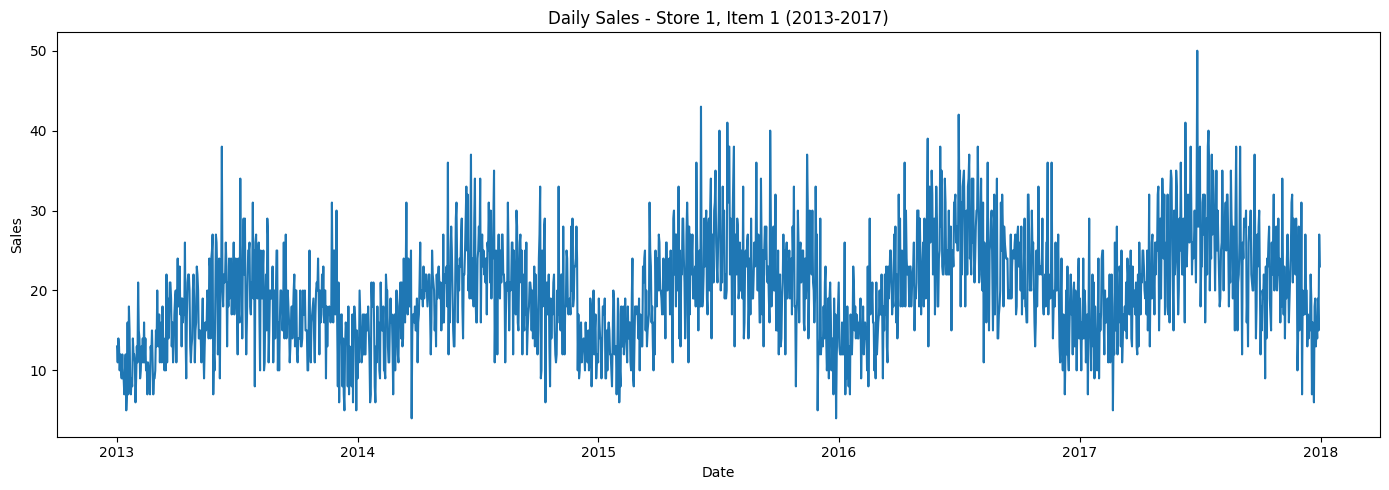

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(ts.index, ts['sales'])
plt.title('Daily Sales - Store 1, Item 1 (2013-2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

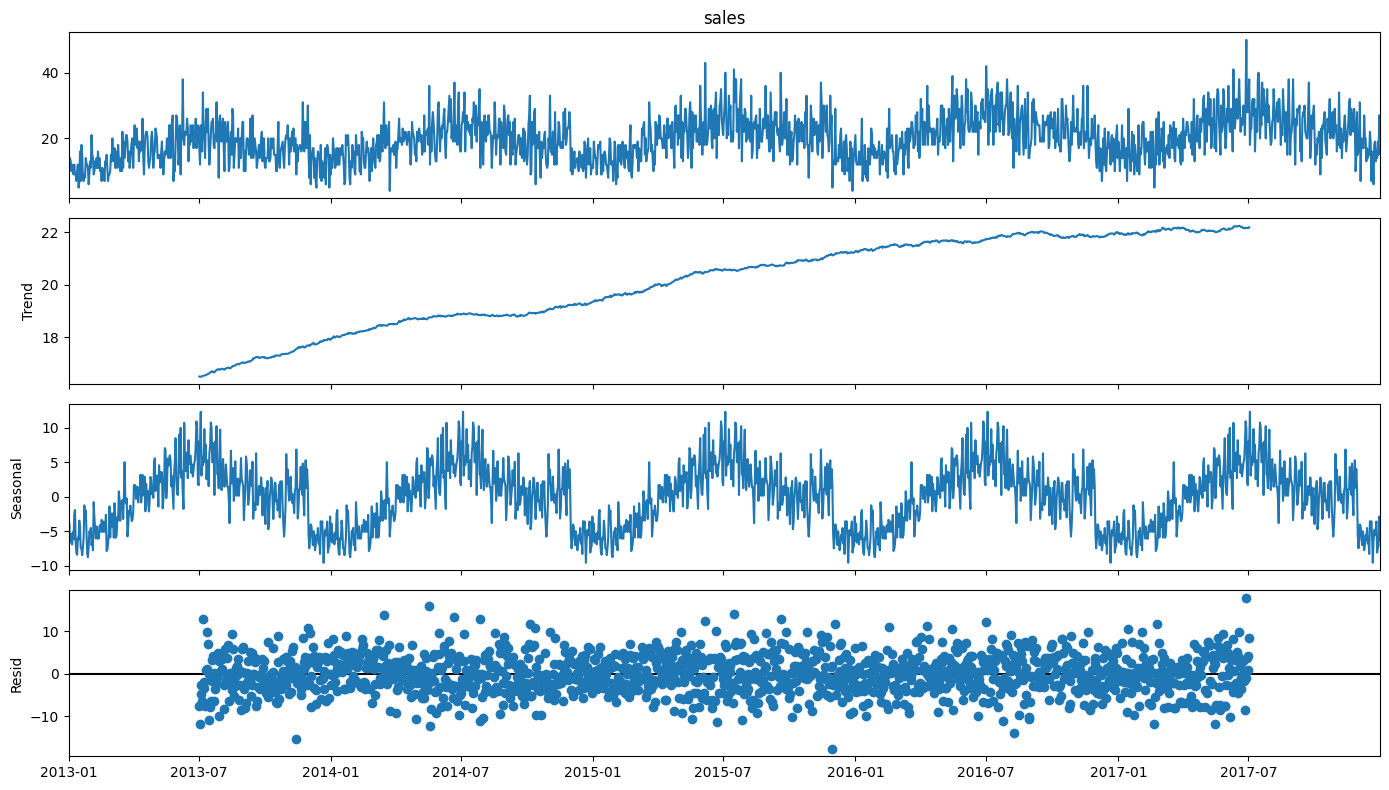

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts['sales'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

In [8]:
train = ts[ts.index < '2017-01-01']
test = ts[ts.index >= '2017-01-01']

print("Train:", train.shape, "Test:", test.shape)

Train: (1461, 1) Test: (365, 1)


In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(train['sales'], 
                                  trend='add', 
                                  seasonal='add', 
                                  seasonal_periods=365).fit()

forecast = hw_model.forecast(len(test))
forecast.head()

c:\Users\malsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\malsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2017-01-01    18.765528
2017-01-02    16.453319
2017-01-03    18.774252
2017-01-04    17.755852
2017-01-05    16.454433
Freq: D, dtype: float64

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['sales'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.516943761311054
RMSE: 7.007725208151837


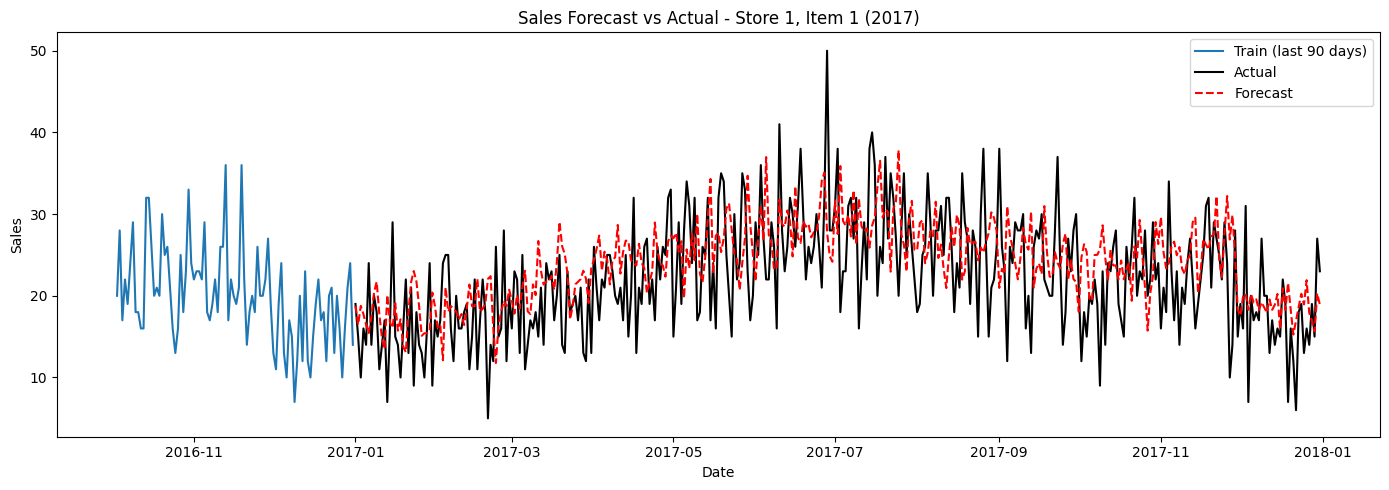

In [11]:
plt.figure(figsize=(14,5))
plt.plot(train.index[-90:], train['sales'][-90:], label='Train (last 90 days)')
plt.plot(test.index, test['sales'], label='Actual', color='black')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title('Sales Forecast vs Actual - Store 1, Item 1 (2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
naive_forecast = train['sales'][-365:].values
naive_forecast = pd.Series(naive_forecast, index=test.index)

naive_mae = mean_absolute_error(test['sales'], naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test['sales'], naive_forecast))

print("Naive Baseline - MAE:", naive_mae, "RMSE:", naive_rmse)
print("Holt-Winters   - MAE:", mae, "RMSE:", rmse)

Naive Baseline - MAE: 6.049315068493151 RMSE: 7.642706255254717
Holt-Winters   - MAE: 5.516943761311054 RMSE: 7.007725208151837


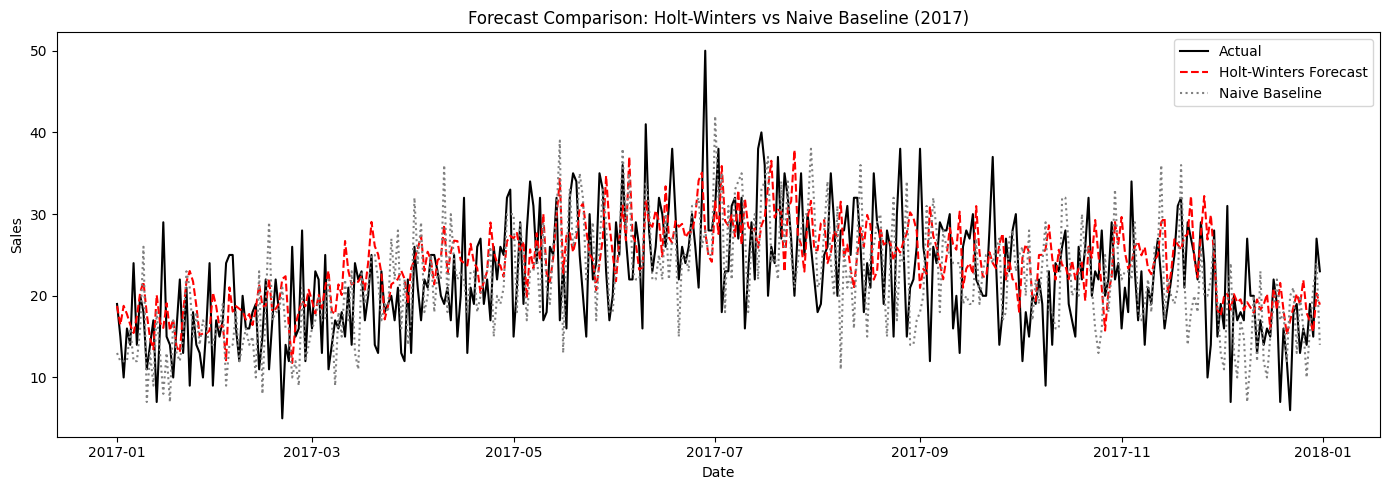

In [13]:
plt.figure(figsize=(14,5))
plt.plot(test.index, test['sales'], label='Actual', color='black')
plt.plot(test.index, forecast, label='Holt-Winters Forecast', color='red', linestyle='--')
plt.plot(test.index, naive_forecast, label='Naive Baseline', color='gray', linestyle=':')
plt.title('Forecast Comparison: Holt-Winters vs Naive Baseline (2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import plotly.graph_objects as go

# Build a comparison for a few different store-item combinations
sample_combos = [(1, 1), (1, 15), (3, 5), (5, 20)]

fig = go.Figure()

for store, item in sample_combos:
    subset = df[(df['store'] == store) & (df['item'] == item)]
    fig.add_trace(go.Scatter(
        x=subset['date'], y=subset['sales'],
        mode='lines', name=f'Store {store}, Item {item}',
        visible=(store == 1 and item == 1)
    ))

buttons = []
for i, (store, item) in enumerate(sample_combos):
    visibility = [False] * len(sample_combos)
    visibility[i] = True
    buttons.append(dict(
        label=f'Store {store}, Item {item}',
        method='update',
        args=[{'visible': visibility}]
    ))

fig.update_layout(
    title='Daily Sales by Store-Item (Interactive)',
    xaxis_title='Date',
    yaxis_title='Sales',
    updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1)]
)

fig.show()